The required libraries are imported, and the dataset is loaded to display its size and sample records.

In [93]:

#Task 1
# Title = Data_analyzer_python
# Demonstrat that how python work in data visulization and also This code demonstrat all 4 python library (
#-numpy
#-pandas
#-matplotlib
#-seaborn
#- also how it use and also load different data base into python.


#1.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#1.3 load dataset csv file using read_csv
df = pd.read_csv("dataset1.csv")
print("Dataset load Succesfully!\n")

#find shape using shape function
print(f"Dataset Shape : {df.shape} \n")
#First 5 record using head()
print(f"First 5 head records of Dataset : \n {df.head()} \n-----------------------------------------------------\n")
#Last 5 recordusing tail()
print(f"Last 5 records of Dataset : \n {df.tail()} \n-----------------------------------------------------\n")





Dataset load Succesfully!

Dataset Shape : (76000, 10) 

First 5 head records of Dataset : 
    Student_ID Enrollment_Date Region       City      Course_Name  \
0     1000000      2022-05-29   West     Mumbai           Python   
1     1000001      2022-01-29    NaN    Chennai  Web Development   
2     1000002      2021-01-22  South    Kolkata  Web Development   
3     1000003      2022-12-15  North       Pune   Cyber Security   
4     1000004      2022-06-07   East  Hyderabad           Python   

  Learning_Mode  Fees_Paid  Attendance_Percent Course_Status Placement_Status  
0       Offline  144770.33                40.0       Ongoing       Not Placed  
1        Hybrid  174792.23                52.0           NaN       Not Placed  
2        Online   92417.81                79.0     Completed           Placed  
3        Online  105916.82                89.0       Dropped       Not Placed  
4       Offline   18927.99                68.0     Completed     Not Eligible   
-----------------

Initial Observations:
- Dataset is cleaned and structured
- Missing values handled successfully
- Duplicate records removed
- Clear variation across courses and regions


In [94]:
#task 2  --  Identify missing value using isnun() then genrrate missing column , then fill that numaric column with 0 ,then print datatype of each column 
#  --then chnge datatype of student_id.

#2.1
print(df.isna())
print("Missing values in each column:")
print(df.isnull().sum())
print("\n ------------------------------------------------------------------")

# Fill null values only in numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print("------------------------------------------------------------------\n")
#2.2
print("\nData types before correction:")
print(df.dtypes)
print("------------------------------------------------------------------\n")

df['Student_ID'] = df['Student_ID'].astype(float)
print("\nData types after correction:")
print(df.dtypes)
print("------------------------------------------------------------------\n")





       Student_ID  Enrollment_Date  Region   City  Course_Name  Learning_Mode  \
0           False            False   False  False        False          False   
1           False            False    True  False        False          False   
2           False            False   False  False        False          False   
3           False            False   False  False        False          False   
4           False            False   False  False        False          False   
...           ...              ...     ...    ...          ...            ...   
75995       False            False   False  False        False          False   
75996       False            False   False  False        False          False   
75997       False            False   False  False        False          False   
75998       False            False   False  False        False          False   
75999       False            False   False  False         True          False   

       Fees_Paid  Attendanc

In [102]:
#-- description  == find duplicate then droup that column then print all statistical summary using describe then find column value count.

#2.3
print("\nNumber of duplicate records:")
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Drop Duplicate data sucessfully!")
print("------------------------------------------------------------------\n")

#2.4
print("\nSummary Statistics:")
print(df.describe())
print("------------------------------------------------------------------\n")

#2.5
print("\nCourse Wise Destibution :")
print(df['Course_Name'].value_counts())
print("------------------------------------------------------------------\n")

print("\nRegion  Wise Destibution :")
print(df['Region'].value_counts())
print("------------------------------------------------------------------\n")


Number of duplicate records:
0
Drop Duplicate data sucessfully!
------------------------------------------------------------------


Summary Statistics:
         Student_ID      Fees_Paid  Attendance_Percent
count  7.200000e+04   72000.000000        72000.000000
mean   1.036000e+06  127405.027434           68.889889
std    2.078475e+04   70797.576088           19.603015
min    1.000000e+06    5003.130000            0.000000
25%    1.018000e+06   66010.192500           54.000000
50%    1.036000e+06  127365.670000           70.000000
75%    1.053999e+06  188838.717500           85.000000
max    1.071999e+06  249992.720000          100.000000
------------------------------------------------------------------


Course Wise Destibution :
Course_Name
Python             13028
AI/ML              12986
Data Science       12817
Web Development    10870
Cyber Security     10838
Cloud Computing     4306
Name: count, dtype: int64
------------------------------------------------------------------



Overall Observations:
- Some courses have higher enrollments
- Higher attendance leads to better completion
- Students paying full fees show better placement
- Certain regions perform better in placements
- Online/Offline learning impacts student success differently

In [101]:
#task 3  -- 

#-- Description:
# This analysis finds how many students are enrolled in each course
# using value_counts() to understand course popularity.
#3.1
print("\nCourse wise enrollment analysis :")
enolled_course = df['Course_Name'].value_counts()
print(enolled_course)
cou = df['Placement_Status'] == "Placed"
print(cou)
print("------------------------------------------------------------------\n")


#-- Description:
# This analysis compares average attendance with course completion status
# to understand the impact of attendance on course completion.
print("\n2. Attendance vs Course Completion")
attendance_completion = df.groupby('Course_Status')['Attendance_Percent'].mean()
print(attendance_completion)
print("------------------------------------------------------------------\n")


#-- Description:
# This code calculates the average fees paid by placed and not placed students
# to understand the relationship between fees and placement outcome.
print("\n3. Fees Paid vs Placement Outcome")
fees_placement = df.groupby('Placement_Status')['Fees_Paid'].mean()
print(fees_placement)
print("------------------------------------------------------------------\n")



#-- Description:
# This analysis shows region-wise placement performance
# using a cross-tabulation of region and placement status.
print("\n4. Region-wise Placement Performance")
region_placement = pd.crosstab(df['Region'], df['Placement_Status'])
print(region_placement)
print("------------------------------------------------------------------\n")



#-- Description:
# This analysis compares learning mode with placement outcome
# to evaluate student success across different learning modes.
print("\n5. Learning Mode vs Student Success")
learning_placement = pd.crosstab(df['Learning_Mode'], df['Placement_Status'])
print(learning_placement)
print("------------------------------------------------------------------\n")






Course wise enrollment analysis :
Course_Name
Python             13028
AI/ML              12986
Data Science       12817
Web Development    10870
Cyber Security     10838
Cloud Computing     4306
Name: count, dtype: int64
0        False
1        False
2         True
3        False
4        False
         ...  
71995    False
71996    False
71997     True
71998    False
71999    False
Name: Placement_Status, Length: 72000, dtype: bool
------------------------------------------------------------------


2. Attendance vs Course Completion
Course_Status
Completed    68.824788
Dropped      68.751656
Ongoing      68.978275
Name: Attendance_Percent, dtype: float64
------------------------------------------------------------------


3. Fees Paid vs Placement Outcome
Placement_Status
Not Eligible    126667.143832
Not Placed      127337.824931
Placed          128138.635880
Name: Fees_Paid, dtype: float64
------------------------------------------------------------------


4. Region-wise Placeme

Chart 1
 --  This chart shows how many students are enrolled in each course under different learning modes.

Chart 2
 -- This chart shows the change in student enrollments from month to month.

 Chart 3
     -- This chart shows how attendance percentages are distributed among students.

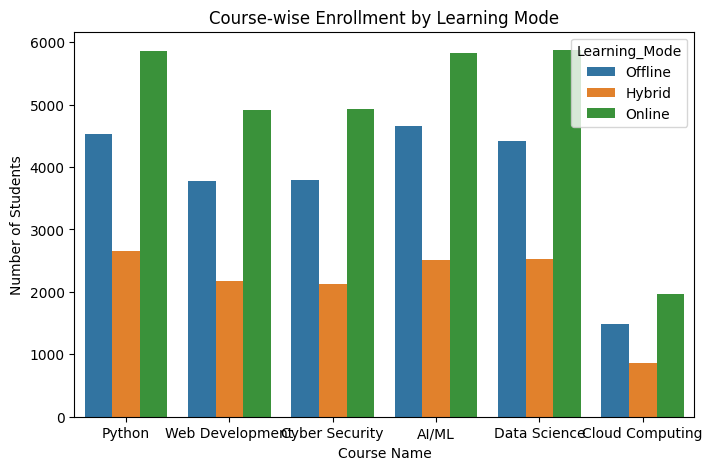

KeyError: 'EnrollmentDate'

In [107]:


#4.1 chart 1
# This bar chart shows course-wise student enrollment
# based on different learning modes like online, offline, and hybrid.
plt.figure(figsize=(8,5))
sns.countplot(x='Course_Name', hue='Learning_Mode', data=df)
plt.title("Course-wise Enrollment by Learning Mode")
plt.xlabel("Course Name")
plt.ylabel("Number of Students")
plt.show()




#4.2 chart 2
# This line chart shows how student enrollment changes month by month
# and helps identify increasing or decreasing trends.
df['Enrollment_Date'] = pd.to_datetime(df['Enrollment_Date'])
trend = df.groupby(df['Enrollment_Date'].dt.month).size().reset_index(name='Count')

plt.figure()
sns.lineplot(x='Enrollment_Date', y='Count', data=trend, marker='o')
plt.title("Enrollment Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Enrollments")
plt.show()




#4.3 chart 3
# This histogram shows how attendance percentages are distributed
# among all students.
plt.figure(figsize=(8,5))
sns.histplot(df['Attendance_Percent'], bins=10, kde=True)
plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.show()


--This pie chart shows the percentage of students who are placed and not placed. It helps to easily understand the overall placement outcome of students.

-- These subplots combine multiple charts into one figure.

The first chart shows how many students are enrolled in each course.

The second chart displays how attendance is distributed among students.

The third chart shows the placement results.

The fourth chart shows the relationship between attendance and fees paid.

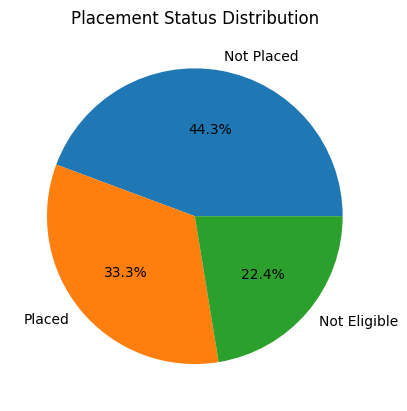

------------------------------------------------------------------



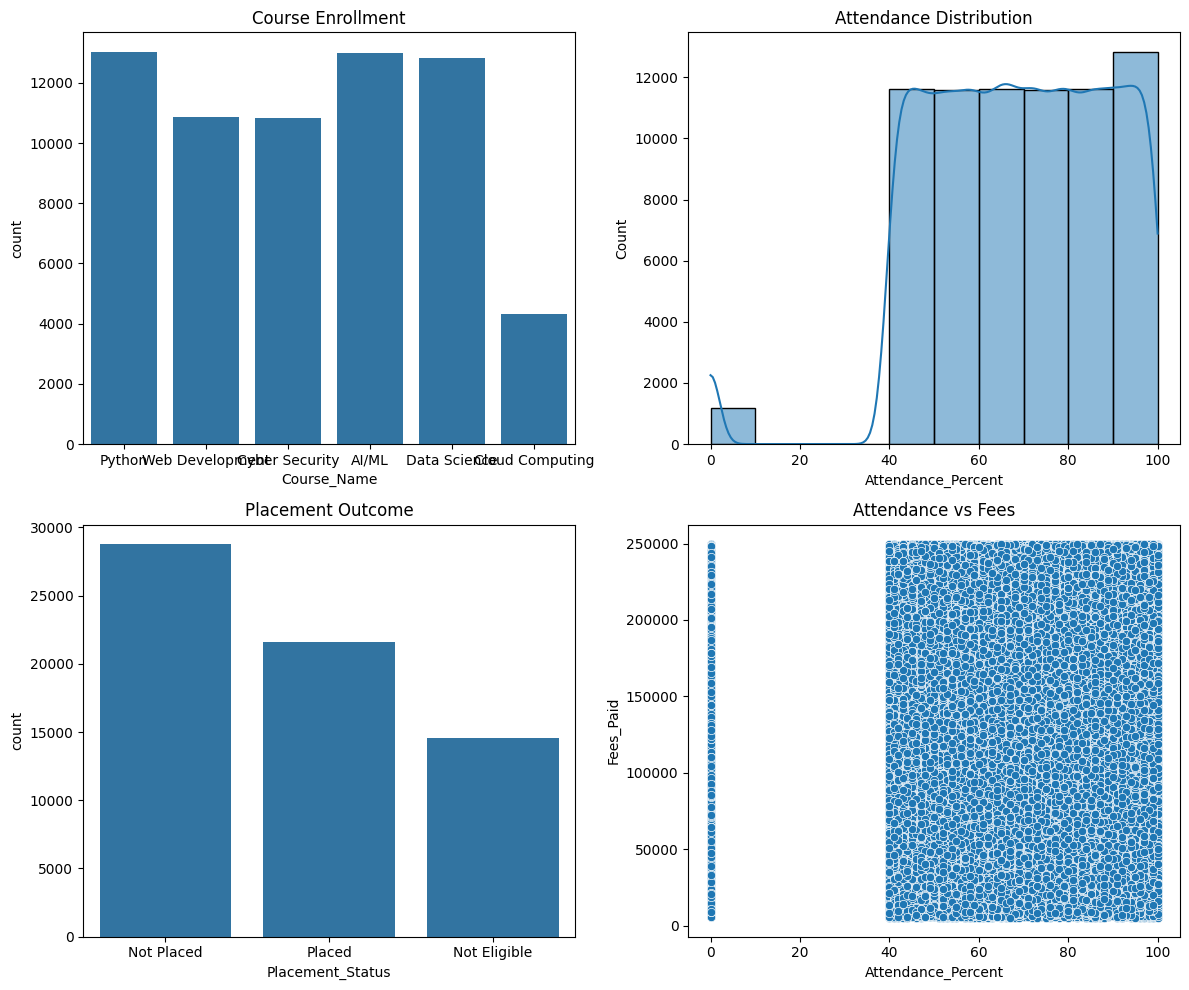

In [99]:
#4.4
#-- Description:
# This pie chart shows the percentage of students who are placed
# and not placed.
placement_counts = df['Placement_Status'].value_counts()

plt.figure()
plt.pie(placement_counts,
        labels=placement_counts.index,
        autopct='%1.1f%%')
plt.title("Placement Status Distribution")
plt.show()
print("------------------------------------------------------------------\n")



#4.5
#-- Description:
# These subplots combine multiple charts to give an overall view
# of enrollment, attendance, placement, and fees in one figure.
#subploat
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.countplot(x='Course_Name', data=df)
plt.title("Course Enrollment")

plt.subplot(2,2,2)
sns.histplot(df['Attendance_Percent'], bins=10, kde=True)
plt.title("Attendance Distribution")

plt.subplot(2,2,3)
sns.countplot(x='Placement_Status', data=df)
plt.title("Placement Outcome")

plt.subplot(2,2,4)
sns.scatterplot(x='Attendance_Percent', y='Fees_Paid', data=df)
plt.title("Attendance vs Fees")

plt.tight_layout()
plt.show()


5. Academic Improvement Recommendations

- Attendance should be checked regularly so that students who are losing interest can be noticed early.
-A mix of online and offline classes can help students stay more involved in learning.
-Students with low attendance need extra academic support and guidance.
-Placement training should be improved in areas where placement results are not very good.
-Course content should be updated so it matches what companies expect from students.

In [98]:
print("1. Key Findings Summary:")

# Most enrolled course
#-- Description:
# This section summarizes key findings like most enrolled course,
# average attendance, and overall course completion rate.


top_course = df['Course_Name'].value_counts().idxmax()
print(f"- Most enrolled course: {top_course}")

avg_attend = df['Attendance_Percent'].mean()
print(f"- Average attendance percentage: {avg_attend:.2f}%")

comp_rate = (df['Course_Status'] == 'Completed').mean() * 100
print(f"- Course completion rate: {comp_rate:.2f}%")
print("------------------------------------------------------------------\n")


#-- Description:
# This analysis compares attendance of completed and dropped students
# to understand the impact of attendance on course completion.
#5.2
comp_att = df[df['Course_Status'] == 'Completed']['Attendance_Percent'].mean()
dropp_at = df[df['Course_Status'] == 'Dropped']['Attendance_Percent'].mean()

print(f"- Avg attendance (Completed students): {comp_att:.2f}%")
print(f"- Avg attendance (Dropped students): {dropp_at:.2f}%")

success = df.groupby('Learning_Mode')['Attendance_Percent'].mean()
print("\n- Learning Mode vs Attendance:")
print(success)
print("------------------------------------------------------------------\n")

#5.3
#-- Description:
# This section analyzes placement performance including overall
# placement rate, region-wise placement, and fees comparison.

print("\n3. Placement Insights:")

# Placement rate
placement = (df['Placement_Status'] == 'Placed').mean() * 100
print(f"- Overall placement rate: {placement:.2f}%")

# Region-wise placement
region_placement = pd.crosstab(df['Region'], df['Placement_Status'])
print("\n- Region-wise Placement Performance:")
print(region_placement)

# Fees vs placement
fees_placed = df[df['Placement_Status'] == 'Placed']['Fees_Paid'].mean()
fees_not_placed = df[df['Placement_Status'] == 'Not Placed']['Fees_Paid'].mean()

print(f"\n- Avg fees paid (Placed): {fees_placed:.2f}")
print(f"- Avg fees paid (Not Placed): {fees_not_placed:.2f}")

1. Key Findings Summary:
- Most enrolled course: Python
- Average attendance percentage: 68.89%
- Course completion rate: 29.61%
------------------------------------------------------------------

- Avg attendance (Completed students): 68.82%
- Avg attendance (Dropped students): 68.75%

- Learning Mode vs Attendance:
Learning_Mode
Hybrid     68.715140
Offline    69.018627
Online     68.866654
Name: Attendance_Percent, dtype: float64
------------------------------------------------------------------


3. Placement Insights:
- Overall placement rate: 29.96%

- Region-wise Placement Performance:
Placement_Status  Not Eligible  Not Placed  Placed
Region                                            
Central                   2211        4297    3336
East                      2143        4337    3231
North                     2191        4322    3275
South                     2232        4352    3227
West                      2239        4253    3271

- Avg fees paid (Placed): 128138.64
- Avg 